# 2. Surface versus depth-following PV-gradient environment

This notebook asks how far the inferred bathymetry and PV-gradient vector move away from their shallow-level values as the detected eddy spine shifts horizontally.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import seacofs_tilt_tools as tilt
import depth_pv_tools as dpt

sns.set_theme(style="whitegrid", context="notebook")
DOMINANCE_FACTOR = 2.0
TARGET_DEPTHS_M = (0, 200, 500, 700, 1000)
MIN_TILT_KM = 5.0

depth_df = tilt.add_pv_gradient_terms(source="depth")
snapshot_df = tilt.add_pv_gradient_terms(source="depth_snapshot")
dpt.validate_depth_tables(depth_df, snapshot_df)
DEPTHS = dpt.nearest_cached_depths(depth_df, TARGET_DEPTHS_M)
comparison = dpt.add_surface_differences(depth_df, DOMINANCE_FACTOR)
matched = dpt.matched_depth_rows(comparison, DEPTHS)
palette = {"AE": "#c44e52", "CE": "#4c72b0"}
depth_cmap = plt.get_cmap("viridis")
depth_colours = dict(zip(DEPTHS, depth_cmap(np.linspace(.08, .92, len(DEPTHS)))))
depth_labels = {z: f"{z:g} m" for z in DEPTHS}


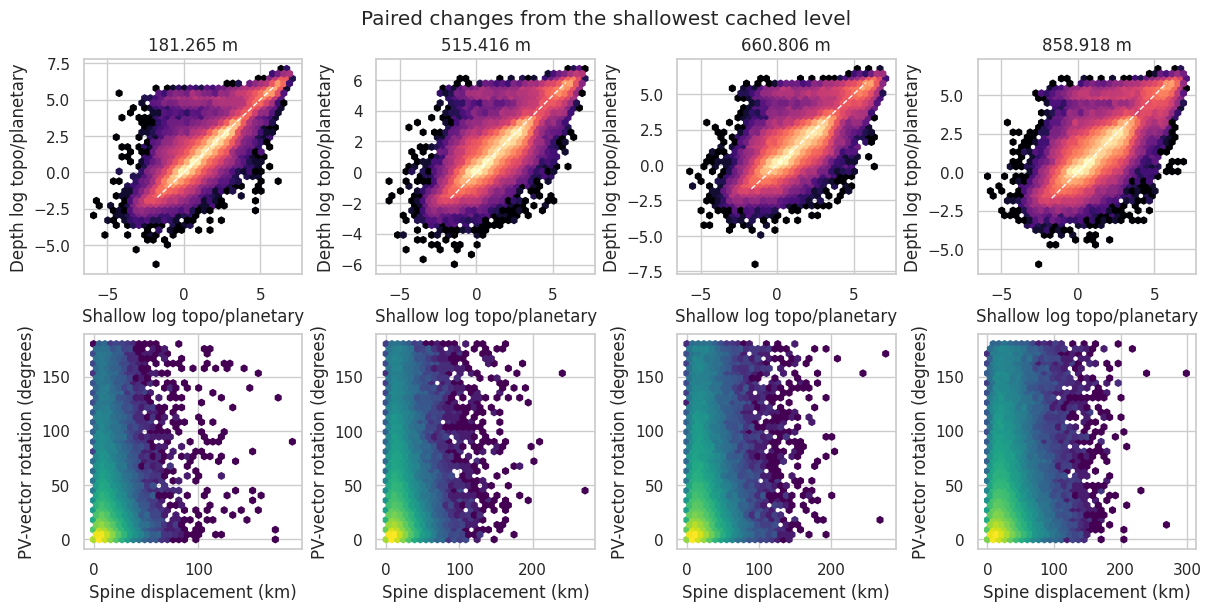

In [5]:
plot = matched[matched.Depth.isin(DEPTHS[1:])].copy()
fig, axes = plt.subplots(2, len(DEPTHS)-1, figsize=(3*(len(DEPTHS)-1), 6), constrained_layout=True)
for j, z in enumerate(DEPTHS[1:]):
    part = plot[np.isclose(plot.Depth, z)]
    hb = axes[0, j].hexbin(part.surface_topo_plan_ratio, part.topo_plan_ratio, gridsize=35, mincnt=1, bins="log", cmap="magma")
    lo, hi = np.nanpercentile(np.r_[part.surface_topo_plan_ratio, part.topo_plan_ratio], [2, 98])
    axes[0, j].plot([lo, hi], [lo, hi], "w--", lw=1)
    axes[0, j].set(title=depth_labels[z], xlabel="Shallow log topo/planetary", ylabel="Depth log topo/planetary")
    axes[1, j].hexbin(part.spine_displacement_km, part.surface_rotation_PV_grad_theta_deg, gridsize=35, mincnt=1, bins="log", cmap="viridis")
    axes[1, j].set(xlabel="Spine displacement (km)", ylabel="PV-vector rotation (degrees)")
fig.suptitle("Paired changes from the shallowest cached level")
plt.show()

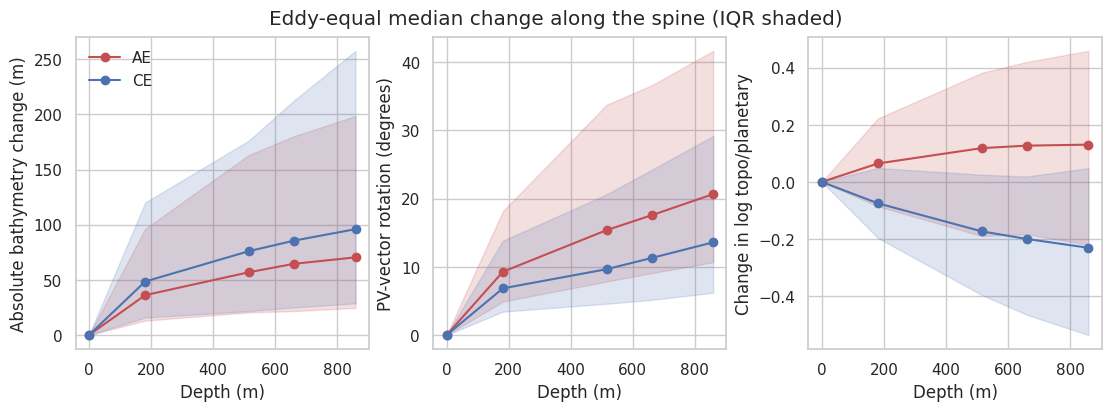

In [6]:
metrics = {
    "abs_delta_h_m": "Absolute bathymetry change (m)",
    "surface_rotation_PV_grad_theta_deg": "PV-vector rotation (degrees)",
    "delta_topo_plan_ratio": "Change in log topo/planetary",
}
fig, axes = plt.subplots(1, 3, figsize=(11, 4), constrained_layout=True)
for ax, (column, label) in zip(axes, metrics.items()):
    summary = dpt.eddy_equal_depth_summary(matched, column)
    for cyc, part in summary.groupby("Cyc"):
        ax.plot(part.Depth, part["median"], color=palette[cyc], marker="o", label=cyc)
        ax.fill_between(part.Depth, part.q25, part.q75, color=palette[cyc], alpha=.18)
    ax.set(xlabel="Depth (m)", ylabel=label)
axes[0].legend(frameon=False); fig.suptitle("Eddy-equal median change along the spine (IQR shaded)")
plt.show()

Large rotations with increasing displacement support the geometric hypothesis: the deeper core samples a different bathymetric setting rather than merely a stronger version of the surface gradient.